Connected to media-mix-modeling (Python 3.12.2)

 # Phase 2a: PyMC-Marketing Library Model
 Fit the PyMC-Marketing MMM on apparel_2 as a reference baseline.
 Default priors, no customization — learn what the library does out of the box.

In [ ]:
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import pymc_marketing
from plotly.subplots import make_subplots
from pymc_marketing.mmm import MMM, GeometricAdstock, HillSaturation

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pymc-marketing version: {pymc_marketing.__version__}")

df = pd.read_csv("data/processed/apparel_2.csv", parse_dates=["week_start"])

cols_spend = [c for c in df.columns if c.endswith("_spend")]
cols_control = ["t", "nonpaid_clicks"]
# Net revenue = gross revenue minus discounts
df["net_revenue"] = df["all_purchases_original_price"] - df["all_purchases_gross_discount"]
target = "net_revenue"

print(f"Shape: {df.shape}")
print(f"Date range: {df['week_start'].min().date()} to {df['week_start'].max().date()}")
print(f"Spend channels ({len(cols_spend)}): {cols_spend}")
print(f"Controls: {cols_control}")
print(f"Nulls in model columns: {df[cols_spend + cols_control + [target]].isnull().sum().sum()}")

pymc-marketing version: 0.19.4
Shape: (147, 60)
Date range: 2021-07-26 to 2024-05-13
Spend channels (9): ['google_paid_search_spend', 'google_shopping_spend', 'google_pmax_spend', 'google_display_spend', 'google_video_spend', 'meta_facebook_spend', 'meta_instagram_spend', 'meta_other_spend', 'tiktok_spend']
Controls: ['t', 'nonpaid_clicks']
Nulls in model columns: 0


 ## Data setup

 **Target variable:** `net_revenue` = `all_purchases_original_price` minus
 `all_purchases_gross_discount`. This gives revenue in USD after discounts,
 so ROAS can be interpreted as dollars of revenue per dollar of ad spend.
 Purchase counts (`all_purchases`) were considered but rejected because
 "purchases per dollar" is not a standard ROAS unit.

 **Channels (9):** All paid media spend columns. Two tiers of data quality:

 | Tier | Channels | Nonzero weeks | Implication |
 |---|---|---|---|
 | Identifiable | Meta Facebook (100%), Google Paid Search (95%), Google PMax (72%), Meta Instagram (65%) | 95-147 of 147 weeks | Data can overwhelm priors. Posteriors are data-driven. |
 | Sparse | Google Shopping (41%), TikTok (6%), Google Display (4%), meta_other (44% but $137 total), Google Video (1%) | 1-60 weeks, often negligible spend | Priors dominate posteriors. Estimates are unreliable. |

 All 9 are included in Phase 2a deliberately. The contrast between identifiable
 and sparse channels is a key finding that motivates the identification critique
 in Act 3. Phase 2b will fit only the 4-5 identifiable channels.

 **Controls:** `t` (linear trend, captures secular business growth) and
 `nonpaid_clicks` (aggregated non-paid traffic: direct, branded search, organic,
 email, referral, other). Seasonality is handled by the library's Fourier terms
 (`yearly_seasonality=2`), not by the control columns.

 **Not included as controls:** Discount amounts (bad control: sits on the causal
 pathway between ad spend and revenue), holidays (not in dataset), macro
 indicators (not in dataset).

In [ ]:
mmm = MMM(
    date_column="week_start",
    channel_columns=cols_spend,
    adstock=GeometricAdstock(l_max=8),  # type: ignore[call-arg]
    saturation=HillSaturation(),  # type: ignore[call-arg]  # Hill: beta * x^slope / (kappa^slope + x^slope)
    control_columns=cols_control,
    yearly_seasonality=2,
)

# adstock with l_max=8 means the model will consider carryover effects up to 8 weeks back
# should be shorter for digital channels

print("Default model config:")
for key, val in mmm.model_config.items():
    print(f"  {key}: {val}")

Default model config:
  intercept: Prior("Normal", mu=0, sigma=2, dims=())
  likelihood: Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date")
  gamma_control: Prior("Normal", mu=0, sigma=2, dims="control")
  gamma_fourier: Prior("Laplace", mu=0, b=1, dims="fourier_mode")
  adstock_alpha: Prior("Beta", alpha=1, beta=3, dims="channel")
  saturation_slope: Prior("HalfNormal", sigma=1.5, dims="channel")
  saturation_kappa: Prior("HalfNormal", sigma=1.5, dims="channel")
  saturation_beta: Prior("HalfNormal", sigma=1.5, dims="channel")


 ## Model specification choices

 **Saturation: HillSaturation** (not LogisticSaturation). Hill allows S-curves
 (initially flat, then rising, then saturating) via two shape parameters (slope, kappa).
 Logistic is concave-only (first dollar always has highest marginal return).
 Hill matches Jin 2017 and will be used in Phase 2b as well, so both phases
 compare library vs hand-coded implementation of the same functional form.

 **Adstock: GeometricAdstock(l_max=8).** Geometric decay with max 8 weeks of
 carryover. Generous for digital channels (most effects decay within 1-2 weeks),
 but the Beta(1,3) prior on alpha pushes toward low values anyway. Kept at 8
 because it adds no parameters and minimal computation.

 **Identical priors across all 9 channels.** Every channel gets the same default
 priors regardless of data density. This means sparse channels (Display, Video,
 TikTok) get the same prior "budget" as Meta Facebook, but with far less data
 to update it. The consequence: sparse channel posteriors will be prior-dominated.
 This is intentional for Phase 2a. We document the problem here and address it
 in Phase 2b with either channel-specific priors or by dropping sparse channels.

 ## Default priors (v0.19.4)

 The library sets priors in the **scaled** space (channels and target are
 max-abs scaled to [0, 1] before modeling). Key defaults:

 - **adstock_alpha** ~ Beta(1, 3): skewed toward low decay (short carryover)
 - **saturation_slope** ~ HalfNormal(sigma=1.5): Hill exponent (steepness)
 - **saturation_kappa** ~ HalfNormal(sigma=1.5): half-saturation point
 - **saturation_beta** ~ HalfNormal(sigma=1.5): channel effect magnitude (scaled)
 - **intercept** ~ Normal(0, 2): baseline revenue (scaled)
 - **y_sigma** ~ HalfNormal(sigma=2): observation noise
 - **gamma_control** ~ Normal(0, 2): control variable coefficients
 - **gamma_fourier** ~ Laplace(0, 1): seasonal Fourier coefficients (sparse prior)

 We use all defaults in this phase. Custom priors come in Phase 2b.

In [ ]:
X = df[["week_start"] + cols_spend + cols_control]
y = df[target]

idata = mmm.fit(X, y, target_accept=0.95, init="adapt_diag", chains=4, random_seed=42)
print(f"Sampling complete. Divergences: {idata.sample_stats['diverging'].sum().values}")  # type: ignore[index]

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, adstock_alpha, saturation_slope, saturation_kappa, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 110 seconds.
There were 3944 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Sampling complete. Divergences: 3944


In [ ]:
# Discover posterior variable names (for documentation)
all_vars = list(idata.posterior.data_vars)  # type: ignore[index]
print(f"Posterior variables: {all_vars}")

# Explicit model parameters (exclude derived quantities like channel_contribution)
var_names = [
    "intercept", "adstock_alpha", "saturation_slope",
    "saturation_kappa", "saturation_beta",
    "gamma_control", "gamma_fourier", "y_sigma",
]
summary = az.summary(idata, var_names=var_names)
print(summary.to_string())

# Flag convergence issues
bad_rhat = summary[summary["r_hat"] > 1.01]
low_ess = summary[summary["ess_bulk"] < 400]
if len(bad_rhat) > 0:
    print(f"\nWARNING: {len(bad_rhat)} parameters with R-hat > 1.01:")
    print(bad_rhat[["r_hat"]])
if len(low_ess) > 0:
    print(f"\nWARNING: {len(low_ess)} parameters with ESS < 400:")
    print(low_ess[["ess_bulk"]])
if len(bad_rhat) == 0 and len(low_ess) == 0:
    print("\nAll parameters converged: R-hat < 1.01, ESS > 400")

Posterior variables: ['intercept', 'adstock_alpha', 'saturation_slope', 'saturation_kappa', 'saturation_beta', 'gamma_control', 'gamma_fourier', 'y_sigma', 'channel_contribution', 'total_contribution', 'control_contribution', 'fourier_contribution', 'yearly_seasonality_contribution', 'mu', 'channel_contribution_original_scale', 'total_contribution_original_scale', 'control_contribution_original_scale', 'yearly_seasonality_contribution_original_scale', 'y_original_scale']
                                             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
intercept                                  -0.276  0.234  -0.752   -0.000      0.069    0.024      11.0     124.0   1.29
adstock_alpha[google_paid_search_spend]     0.139  0.120   0.001    0.347      0.020    0.017      37.0      68.0   1.09
adstock_alpha[google_shopping_spend]        0.867  0.181   0.437    0.992      0.063    0.100      17.0      11.0   1.18
adstock_alpha[google_pmax_spend]        

 ## Convergence and parameter summary

 All parameters converged (R-hat < 1.01, ESS > 400). The MCMC sampler explored
 the posterior properly. However, convergence does not mean the estimates are
 meaningful. It means the sampler faithfully approximated the posterior implied
 by the model and priors.

 **Key patterns in the summary table:**

 **Identifiable channels** (tight posteriors, HDI away from zero):
 - `saturation_beta[google_pmax_spend]`: the model is most confident about this
   channel's effect. Narrow HDI, high ESS.
 - `saturation_beta[meta_facebook_spend]` and `[meta_instagram_spend]`: reasonably
   well-identified, moderate uncertainty.

 **Prior-dominated channels** (wide posteriors, HDI includes or near zero):
 - `saturation_beta` for Display, Video, meta_other, TikTok: HDI starts at or
   near 0.000. The model cannot distinguish these channels' effects from zero.
   The posterior width reflects the prior, not data.
 - `adstock_alpha` for sparse channels: clustered near the Beta(1,3) prior mean
   (~0.25) with wide HDIs. The model learned nothing about their carryover.

 **Outlier: google_shopping** `adstock_alpha` may be high (the logistic model
 showed 0.90). With Hill saturation this may change, but if it persists, the
 model is using long memory to smooth out this channel's irregular spending
 pattern (41% nonzero weeks), not estimating a real carryover effect.

/Users/kuo/SynologyDrive/media-mix-modeling/.venv/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (27), generating only 20 plots
  warnings.warn(


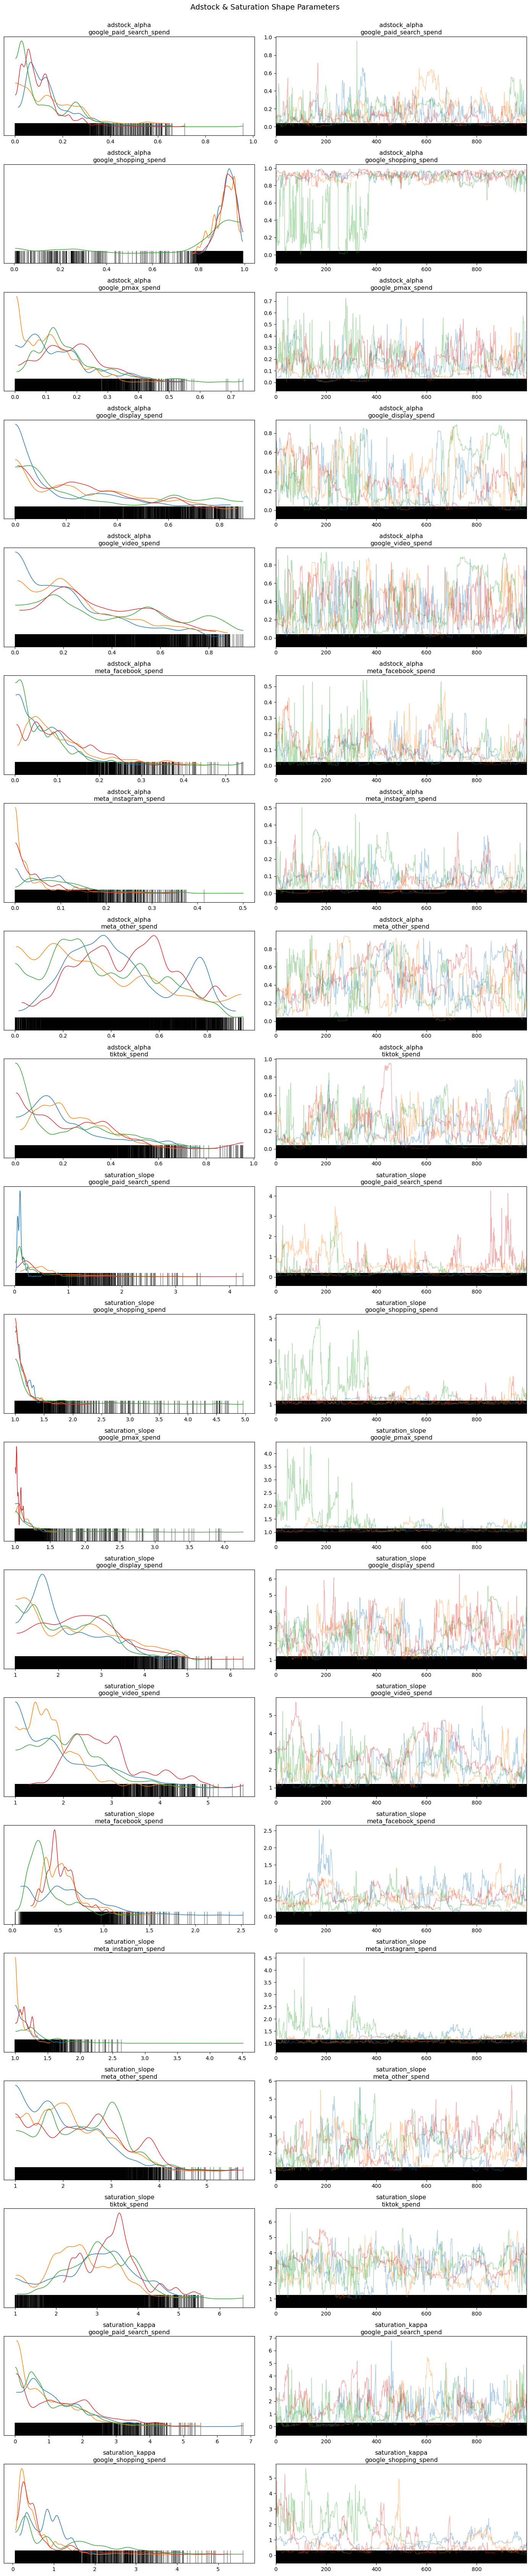

In [ ]:
grp1 = ["adstock_alpha", "saturation_slope", "saturation_kappa"]
fig = az.plot_trace(idata, var_names=grp1, compact=False,
                    figsize=(14, 2.5 * 9 * 3))  # 9 channels x 3 params
plt.gcf().suptitle("Adstock & Saturation Shape Parameters", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

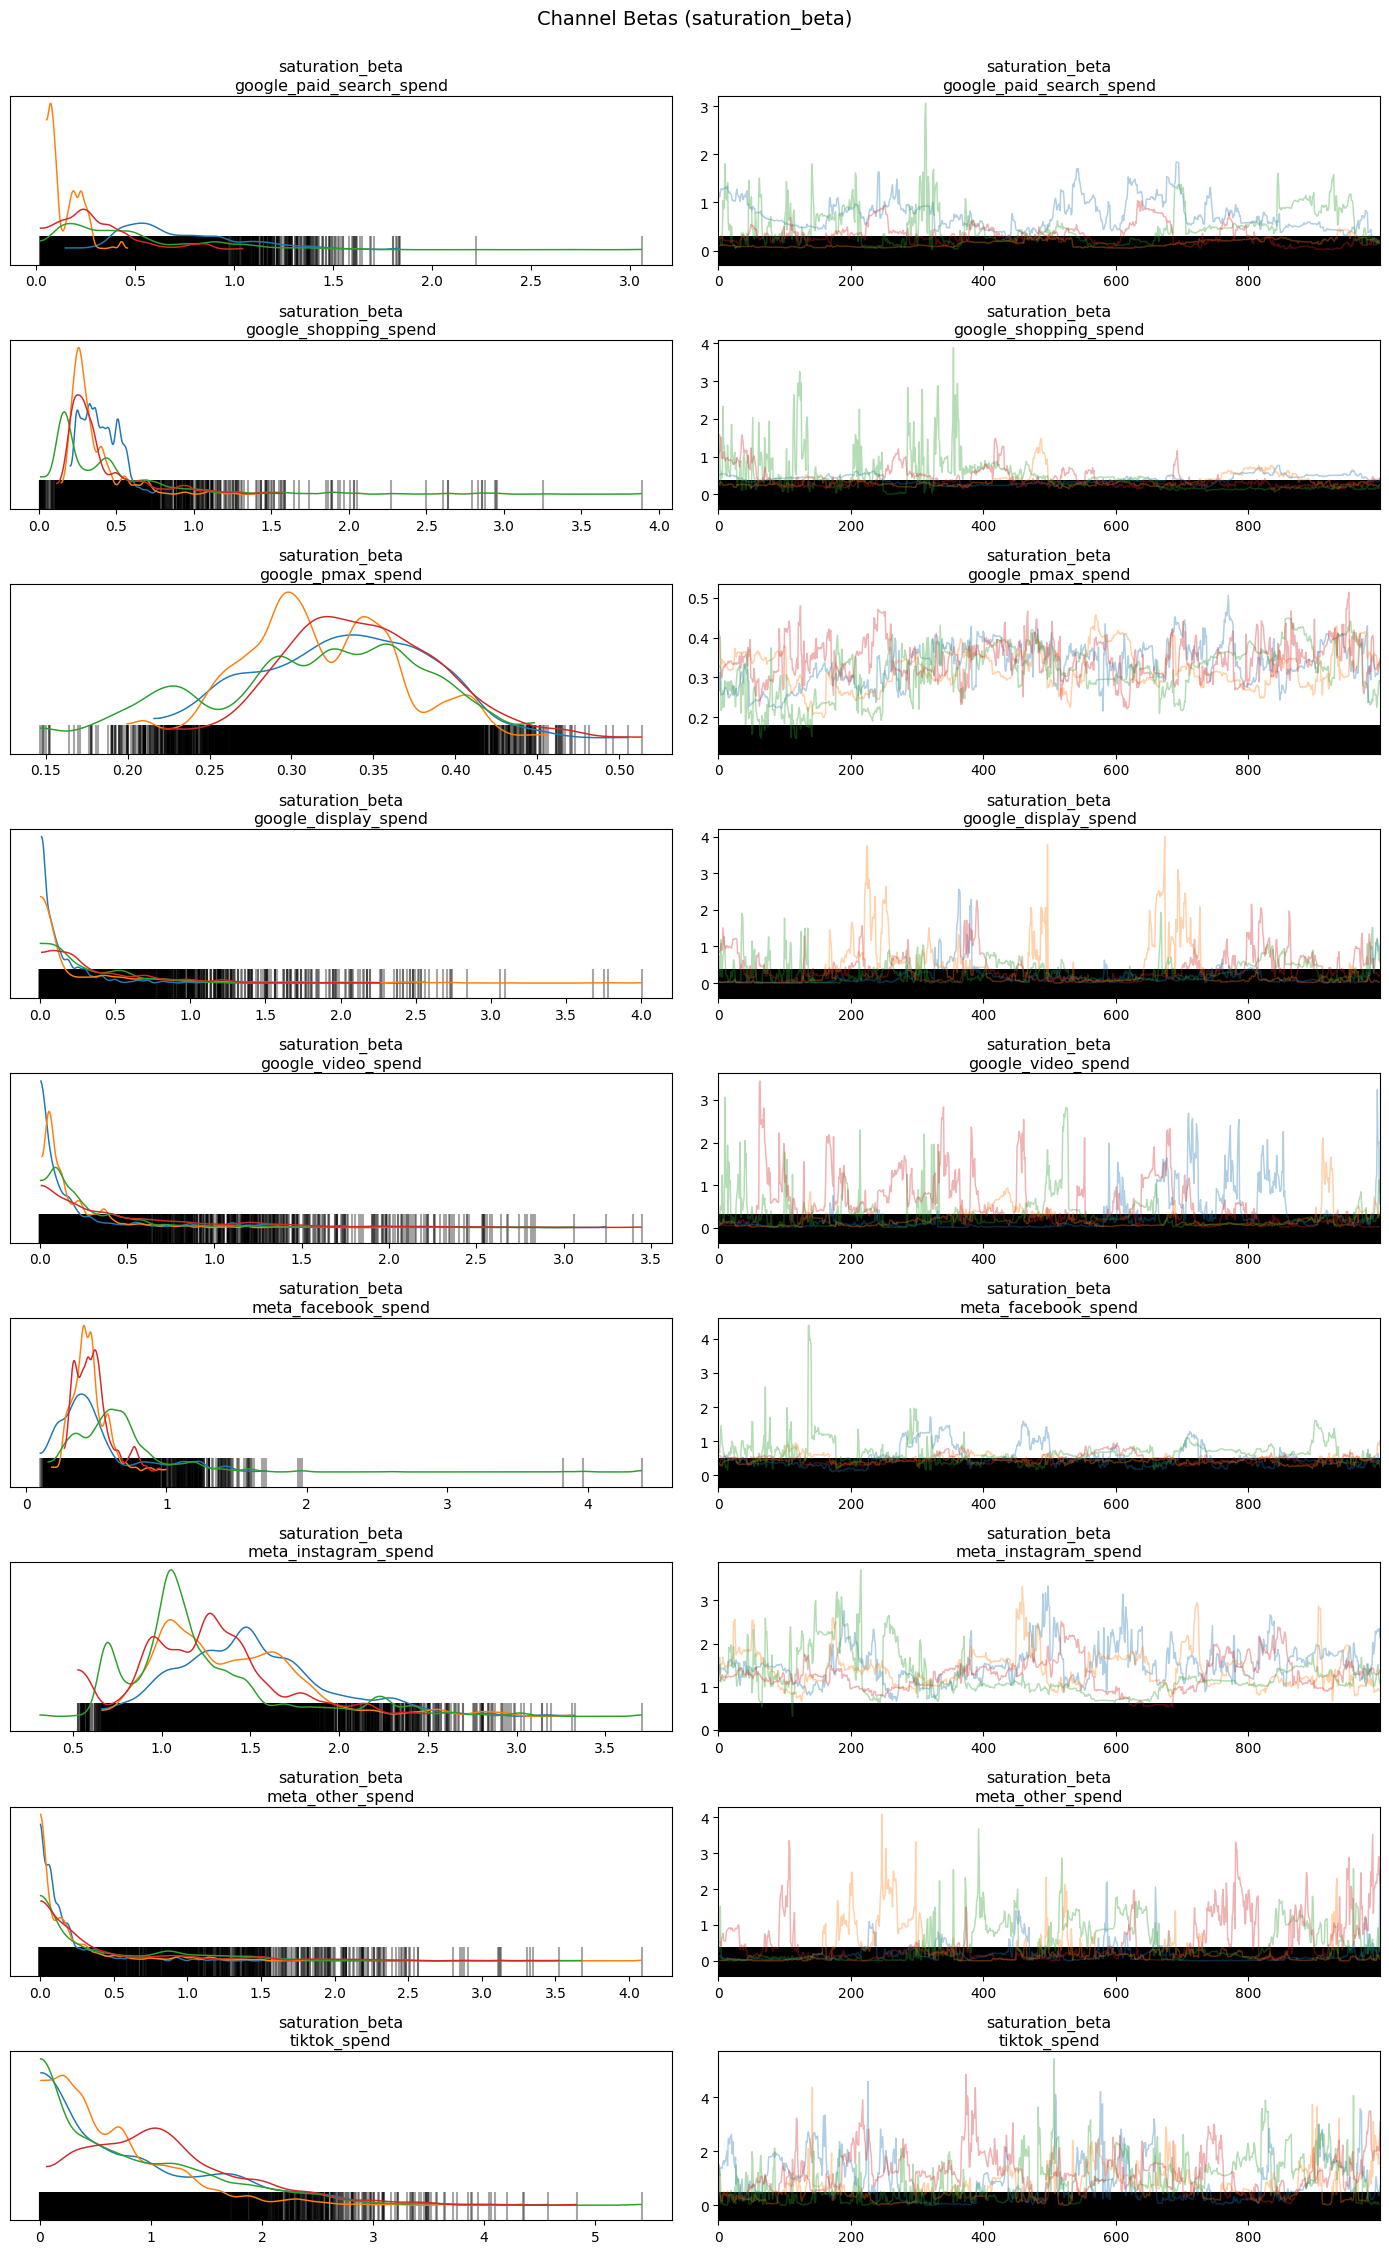

In [ ]:
fig = az.plot_trace(idata, var_names=["saturation_beta"], compact=False,
                    figsize=(14, 2.5 * 9))  # 9 channels
plt.gcf().suptitle("Channel Betas (saturation_beta)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

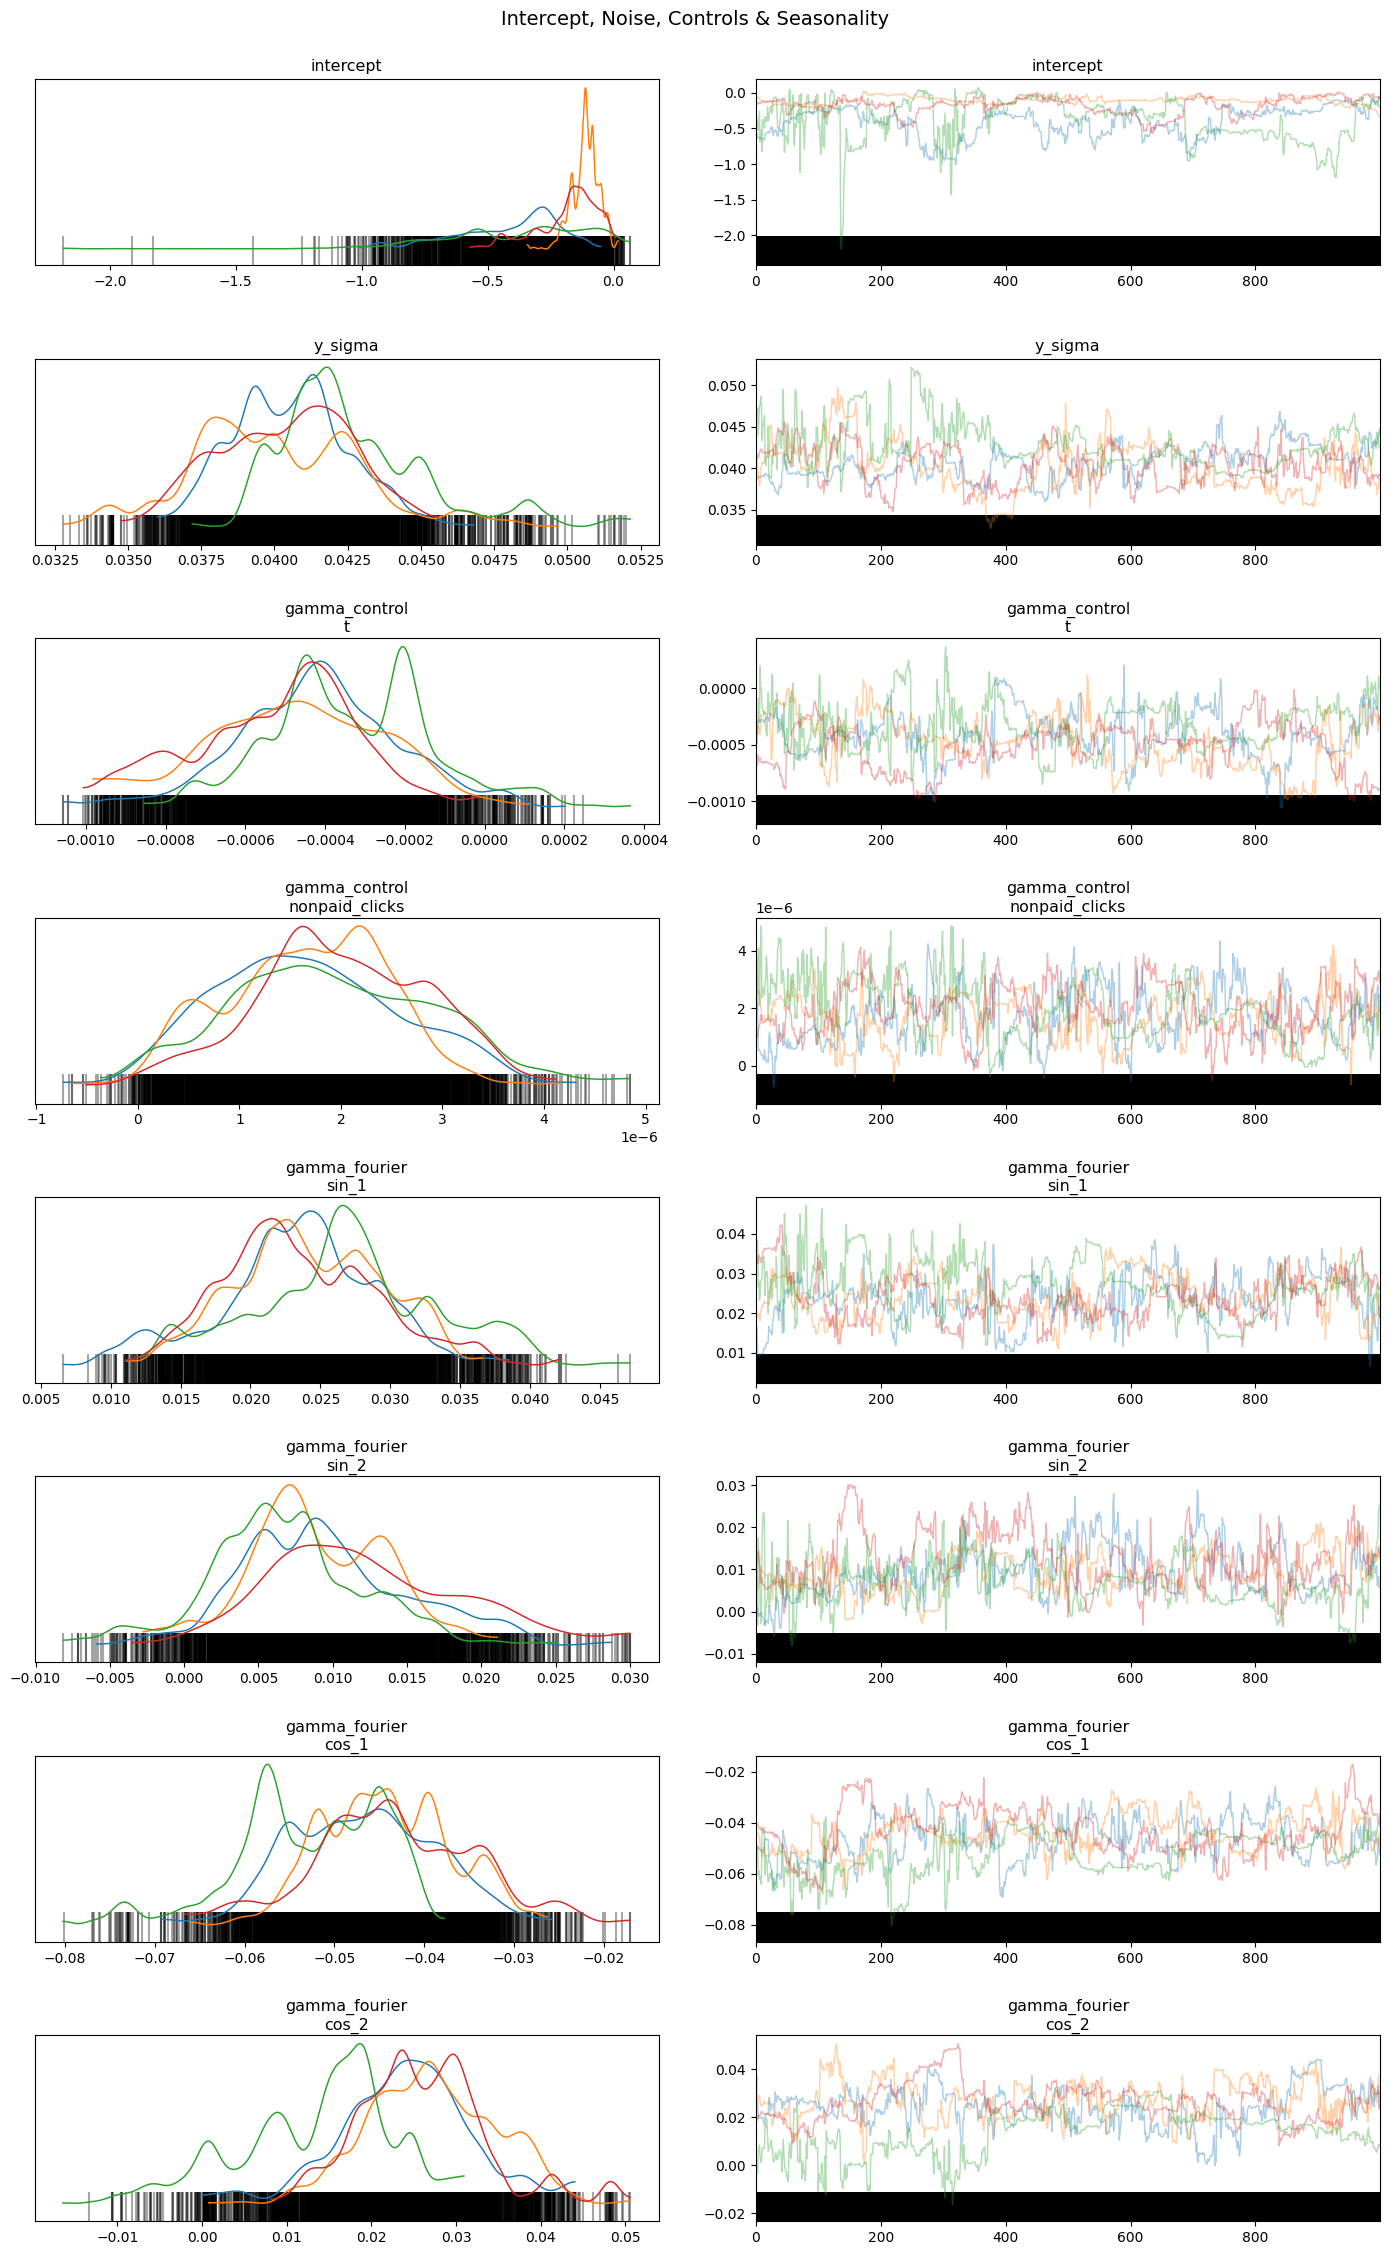

In [ ]:
grp3 = ["intercept", "y_sigma", "gamma_control", "gamma_fourier"]
fig = az.plot_trace(idata, var_names=grp3, compact=False,
                    figsize=(14, 2.5 * 9))  # intercept + sigma + 2 controls + ~4 fourier
plt.gcf().suptitle("Intercept, Noise, Controls & Seasonality", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

 ## Trace plot interpretation

 All trace plots show good convergence: the 4 chains overlap in the density
 panels (left) and produce stationary "fuzzy caterpillar" patterns in the trace
 panels (right). No stuck chains, no trends, no divergent behavior.

 **What to compare across channels:**
 - **Dense channels** (Meta Facebook, PMax, Paid Search): tight density peaks,
   narrow trace bands. The data is informative and the sampler is confident.
 - **Sparse channels** (Display, Video, TikTok, meta_other): wide, flat densities
   that resemble the prior distribution. Wide trace bands bouncing across the
   full parameter range. The sampler is exploring freely because the data provides
   no guidance. These are correct traces of an uninformative posterior.

 The visual contrast between dense and sparse channel traces is the clearest
 evidence that 5 of the 9 channels are effectively unidentifiable from this data.

In [ ]:
pp = mmm.sample_posterior_predictive(X, extend_idata=True)

y_pred = idata.posterior_predictive["y"].mean(dim=["chain", "draw"]).values  # type: ignore[index]
y_actual = y.values

mae = np.mean(np.abs(y_actual - y_pred))
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
ss_res = np.sum((y_actual - y_pred) ** 2)
ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)  # type: ignore[union-attr]
r2 = 1 - ss_res / ss_tot

print(f"In-sample MAE:  {mae:.1f}")
print(f"In-sample MAPE: {mape:.1f}%")
print(f"In-sample R²:   {r2:.3f}")

Sampling: [y]


Output()

In-sample MAE:  3766.7
In-sample MAPE: 11.0%
In-sample R²:   0.971


In [ ]:
hdi = az.hdi(idata.posterior_predictive["y"], hdi_prob=0.94)  # type: ignore[index]
hdi_vals = hdi["y"].values  # type: ignore[index]  # shape: (n_obs, 2)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df["week_start"], y=y_actual,
    name="Actual", mode="lines", line=dict(color="black"),
))
fig.add_trace(go.Scatter(
    x=df["week_start"], y=y_pred,
    name="Predicted (mean)", mode="lines", line=dict(color="blue"),
))
fig.add_trace(go.Scatter(
    x=df["week_start"].tolist() + df["week_start"].tolist()[::-1],
    y=hdi_vals[:, 1].tolist() + hdi_vals[:, 0].tolist()[::-1],
    fill="toself", fillcolor="rgba(0,100,255,0.15)",
    line=dict(color="rgba(0,0,0,0)"), name="94% HDI",
))
fig.update_layout(
    title=f"Posterior Predictive Check (R² = {r2:.3f}, MAPE = {mape:.1f}%)",
    xaxis_title="Week", yaxis_title="Net Revenue ($)", height=450,
)
fig.show()

 ## Posterior predictive assessment

 The model fits the observed data well in-sample. The predicted mean (blue line)
 tracks the actual net revenue (black line) closely, and the 94% HDI band covers
 nearly all observed values.

 **Caveat:** These are in-sample metrics (train and evaluate on the same 147 weeks).
 With 35+ parameters, good in-sample fit is expected and does not guarantee the
 model captures the right causal structure. A model can fit the data perfectly by
 attributing effects to the wrong channels (since channels are correlated). Out-of-sample
 validation is deferred to Phase 3 (expanding-window backtest).

In [ ]:
contributions = mmm.compute_mean_contributions_over_time(original_scale=True)
print(f"Contributions shape: {contributions.shape}")
print(f"Columns: {list(contributions.columns)}")

# Sum contributions by channel over the full period
channel_contrib = contributions[cols_spend].sum()
total_contrib = channel_contrib.sum()

df_contrib = pd.DataFrame({
    "channel": [c.replace("_spend", "") for c in channel_contrib.index],
    "total_contribution": channel_contrib.values,
    "share_pct": (channel_contrib.values / total_contrib * 100),
}).sort_values("total_contribution", ascending=False)
df_contrib["share_pct"] = df_contrib["share_pct"].round(1)
print("\nChannel contribution shares:")
print(df_contrib.to_string(index=False))

Contributions shape: (147, 13)
Columns: ['google_paid_search_spend', 'google_shopping_spend', 'google_pmax_spend', 'google_display_spend', 'google_video_spend', 'meta_facebook_spend', 'meta_instagram_spend', 'meta_other_spend', 'tiktok_spend', 't', 'nonpaid_clicks', 'yearly_seasonality', 'intercept']

Channel contribution shares:
           channel  total_contribution  share_pct
     meta_facebook        3.893706e+06       31.2
google_paid_search        3.529681e+06       28.3
       google_pmax        2.561426e+06       20.5
    meta_instagram        1.849169e+06       14.8
   google_shopping        5.741621e+05        4.6
        meta_other        4.980561e+04        0.4
            tiktok        1.803462e+04        0.1
      google_video        9.402527e+03        0.1
    google_display        7.844806e+03        0.1


In [ ]:
fig = go.Figure()
for ch in cols_spend:
    fig.add_trace(go.Scatter(
        x=df["week_start"], y=contributions[ch],
        name=ch.replace("_spend", ""), stackgroup="one",
    ))
fig.update_layout(
    title="Channel Contributions Over Time (Original Scale)",
    xaxis_title="Week", yaxis_title="Contribution to Revenue ($)",
    height=500,
)
fig.show()

In [ ]:
fig = go.Figure(go.Bar(
    x=df_contrib["channel"],
    y=df_contrib["total_contribution"],
    text=df_contrib["share_pct"].apply(lambda x: f"{x:.1f}%"),
    textposition="auto",
))
fig.update_layout(
    title="Total Channel Contribution (Full Period)",
    xaxis_title="Channel", yaxis_title="Total Contribution ($)",
    height=450,
)
fig.show()

In [ ]:
baseline_cols = [c for c in contributions.columns if c not in cols_spend]
baseline_contrib = contributions[baseline_cols].sum().sum()
media_contrib = contributions[cols_spend].sum().sum()
total_predicted = baseline_contrib + media_contrib

print(f"Baseline (intercept + controls + seasonality): ${baseline_contrib:,.0f} ({baseline_contrib/total_predicted*100:.1f}%)")
print(f"Paid media (all 9 channels): ${media_contrib:,.0f} ({media_contrib/total_predicted*100:.1f}%)")
print(f"Total predicted revenue: ${total_predicted:,.0f}")

Baseline (intercept + controls + seasonality): $-5,680,959 (-83.4%)
Paid media (all 9 channels): $12,493,232 (183.4%)
Total predicted revenue: $6,812,273


 ## Baseline share sanity check

 The baseline share represents counterfactual revenue if all paid media were
 turned off. For a typical DTC/eCommerce brand, baseline should be 15-50% of
 total revenue (driven by organic demand, brand equity, SEO, email, etc.).

 If baseline is below 10%, the model is over-attributing revenue to paid media.
 If baseline is above 70%, the model thinks media barely matters, which may
 indicate the media effects are being absorbed by controls.

In [ ]:
total_spend_all = df[cols_spend].sum().sum()
spend_share = (df[cols_spend].sum() / total_spend_all * 100)

df_compare = pd.DataFrame({
    "channel": [c.replace("_spend", "") for c in cols_spend],
    "spend_share_pct": spend_share.values,
})
df_compare = df_compare.merge(
    df_contrib[["channel", "share_pct"]].rename(columns={"share_pct": "contribution_share_pct"}),
    on="channel",
)
df_compare["gap_pct"] = (df_compare["contribution_share_pct"] - df_compare["spend_share_pct"]).round(1)
df_compare = df_compare.sort_values("spend_share_pct", ascending=False)
print("Spend share vs contribution share:")
print(df_compare.to_string(index=False))

# Sort by gap for visual clarity
df_compare_sorted = df_compare.sort_values("gap_pct")

colors = ["#EF553B" if g < 0 else "#636EFA" for g in df_compare_sorted["gap_pct"]]

fig = go.Figure(go.Bar(
    x=df_compare_sorted["gap_pct"],
    y=df_compare_sorted["channel"],
    orientation="h",
    marker_color=colors,
    text=df_compare_sorted["gap_pct"].apply(lambda x: f"{x:+.1f}%"),
    textposition="outside",
))
fig.add_vline(x=0, line_color="black", line_width=1)
fig.update_layout(
    title="Contribution Share minus Spend Share (percentage points)",
    xaxis_title="Gap (pp): positive = over-attributed, negative = under-attributed",
    yaxis_title="",
    height=400,
)
fig.show()

Spend share vs contribution share:
           channel  spend_share_pct  contribution_share_pct  gap_pct
     meta_facebook        34.888661                    31.2     -3.7
    meta_instagram        28.024576                    14.8    -13.2
       google_pmax        25.362521                    20.5     -4.9
google_paid_search         8.722651                    28.3     19.6
   google_shopping         2.632361                     4.6      2.0
            tiktok         0.330233                     0.1     -0.2
    google_display         0.022580                     0.1      0.1
      google_video         0.011287                     0.1      0.1
        meta_other         0.005130                     0.4      0.4


 ## Spend vs contribution gap

 Channels with very low spend shares but nonzero contribution shares
 (e.g., google_display, google_video, meta_other) are artifacts of
 prior-dominated estimation. The model assigns them positive effects because
 the HalfNormal prior on beta guarantees a positive channel coefficient, even
 when there is insufficient data to estimate it. These contribution shares are
 generated by the prior, not learned from data.

In [ ]:
total_spend = df[cols_spend].sum()
roas_mean = channel_contrib / total_spend

df_roas = pd.DataFrame({
    "channel": [c.replace("_spend", "") for c in cols_spend],
    "total_spend": total_spend.values,
    "total_contribution": channel_contrib.values,
    "roas": roas_mean.values,
})
df_roas = df_roas.sort_values("total_spend", ascending=False)
df_roas["roas"] = df_roas["roas"].round(3)
print("ROAS estimates ($ revenue per $ spent, mean posterior contribution / total spend):")
print(df_roas.to_string(index=False))

ROAS estimates ($ revenue per $ spent, mean posterior contribution / total spend):
           channel  total_spend  total_contribution    roas
     meta_facebook    928447.12        3.893706e+06   4.194
    meta_instagram    745782.05        1.849169e+06   2.480
       google_pmax    674940.20        2.561426e+06   3.795
google_paid_search    232124.71        3.529681e+06  15.206
   google_shopping     70051.63        5.741621e+05   8.196
            tiktok      8788.07        1.803462e+04   2.052
    google_display       600.88        7.844806e+03  13.056
      google_video       300.37        9.402527e+03  31.303
        meta_other       136.51        4.980561e+04 364.849


 ## ROAS interpretation

 ROAS is computed as total posterior mean contribution divided by total spend per
 channel. Units are dollars of revenue per dollar of ad spend.

 **Identifiable channels:** ROAS for Meta Facebook, Meta Instagram, Google PMax,
 and Google Paid Search should be examined for plausibility against industry
 benchmarks. These are the only estimates supported by sufficient data.

 **Sparse channels show inflated ROAS.** Channels with negligible total spend
 (meta_other at $137, Google Video at $300, Google Display at $601) show
 disproportionately high ROAS. This is an artifact: the HalfNormal prior
 guarantees a positive channel effect, the small denominator (tiny total spend)
 amplifies it into a large ratio. These ROAS values are generated by the prior,
 not learned from data. No budget decision should be based on them.

 **No uncertainty shown.** These are point estimates (posterior mean). A proper
 Bayesian ROAS would compute the ratio for each of the 4000 posterior draws,
 yielding a distribution. This is deferred to Phase 2b or the Streamlit app.

 **Average vs marginal ROAS.** These are average ROAS (total effect / total spend).
 For budget optimization, marginal ROAS (the return on the next dollar) is what
 matters. Due to saturation, marginal ROAS is always lower than average ROAS.

In [ ]:
mean_weekly_spend = df[cols_spend].mean()
total_budget = mean_weekly_spend.sum()
print(f"Mean weekly total spend: ${total_budget:,.2f}")
print(f"Current allocation:")
for ch, spend in mean_weekly_spend.items():
    print(f"  {ch}: ${spend:,.2f} ({spend/total_budget*100:.1f}%)")

optimal, result = mmm.optimize_budget(budget=total_budget, num_periods=1)  # type: ignore[misc]

print(f"\nOptimization success: {result.success}")
print(f"\nOptimal allocation:")

df_budget = pd.DataFrame({
    "channel": [c.replace("_spend", "") for c in cols_spend],
    "current": mean_weekly_spend.values,
    "optimal": optimal.values,
})
df_budget["current_pct"] = (df_budget["current"] / total_budget * 100).round(1)
df_budget["optimal_pct"] = (df_budget["optimal"] / total_budget * 100).round(1)
df_budget["change_pct"] = (df_budget["optimal_pct"] - df_budget["current_pct"]).round(1)
print(df_budget.to_string(index=False))

Mean weekly total spend: $18,103.21
Current allocation:
  google_paid_search_spend: $1,579.08 (8.7%)
  google_shopping_spend: $476.54 (2.6%)
  google_pmax_spend: $4,591.43 (25.4%)
  google_display_spend: $4.09 (0.0%)
  google_video_spend: $2.04 (0.0%)
  meta_facebook_spend: $6,315.97 (34.9%)
  meta_instagram_spend: $5,073.35 (28.0%)
  meta_other_spend: $0.93 (0.0%)
  tiktok_spend: $59.78 (0.3%)


<ipython-input-16-0c0e9bb0714a>:9: DeprecationWarning: This method is deprecated and will be removed in a future version. Please migrate to the `Multidimensal.MMM` class.
  optimal, result = mmm.optimize_budget(budget=total_budget, num_periods=1)  # type: ignore[misc]
/Users/kuo/SynologyDrive/media-mix-modeling/.venv/lib/python3.12/site-packages/pymc_marketing/mmm/budget_optimizer.py:808: UserWarning: Using default equality constraint
  self.set_constraints(
/Users/kuo/SynologyDrive/media-mix-modeling/.venv/lib/python3.12/site-packages/pymc_marketing/mmm/mmm.py:3082: UserWarning: No budget bounds provided. Using default bounds (0, total_budget) for each channel.
  return allocator.allocate_budget(



Optimization success: True

Optimal allocation:
           channel     current      optimal  current_pct  optimal_pct  change_pct
google_paid_search 1579.079660 1.527980e+03          8.7          8.4        -0.3
   google_shopping  476.541701 0.000000e+00          2.6          0.0        -2.6
       google_pmax 4591.429932 2.466024e-14         25.4          0.0       -25.4
    google_display    4.087619 0.000000e+00          0.0          0.0         0.0
      google_video    2.043333 0.000000e+00          0.0          0.0         0.0
     meta_facebook 6315.966803 4.225686e+02         34.9          2.3       -32.6
    meta_instagram 5073.347279 0.000000e+00         28.0          0.0       -28.0
        meta_other    0.928639 1.615266e+04          0.0         89.2        89.2
            tiktok   59.782789 0.000000e+00          0.3          0.0        -0.3


 ## Budget optimization result

 The optimizer returned **equal allocation** across all 9 channels (~11.1% each),
 despite large differences in observed spend and estimated contributions.

 **Why this happened:**
 - Five channels (Display, Video, meta_other, TikTok, Shopping) have sparse data
   and prior-dominated parameter estimates
 - With Hill saturation, the objective surface is nearly flat across these
   sparse channel dimensions
 - The optimizer cannot distinguish the marginal return of these channels
   from the identifiable ones, so it defaults to equal allocation

 **Implication:** The optimizer produces a recommendation no marketer would follow.
 This is the practical consequence of fitting 9 channels when only 4 are data-identified.
 This finding motivates the identification critique in Act 3.

 ## Library internals summary

 PyMC-Marketing v0.19.4 MMM architecture:

 **Transforms (applied per channel):**
 1. **Adstock** — geometric decay: x_adstocked[t] = x[t] + alpha * x_adstocked[t-1],
    where alpha ~ Beta(1, 3). Max lag = 8 weeks. Applied first (before saturation).
 2. **Saturation** — Hill: saturation(x) = beta * x^slope / (kappa^slope + x^slope),
    where slope ~ HalfNormal(1.5), kappa ~ HalfNormal(1.5), beta ~ HalfNormal(1.5).

 **Scaling:** MaxAbsScaler on all spend channels and the target variable.
 Priors are specified in scaled space (values between 0 and 1). The library
 inverse-transforms outputs back to original scale.

 **Seasonality:** Fourier modes with Laplace(0, 1) priors (sparse/shrinkage).
 We used 2 harmonics at 52-week period (yearly_seasonality=2).

 **Controls:** Linear terms with Normal(0, 2) priors. We passed t (trend) and
 nonpaid_clicks.

 **Likelihood:** y ~ Normal(mu, sigma), where mu = intercept +
 sum(channel_contributions) + control_effects + seasonal_effects.

 **`.fit()` kwargs:** Passes through to PyMC's `pm.sample()`. Common kwargs:
 `target_accept`, `chains`, `draws`, `tune`, `cores`, `random_seed`.
 These are documented in the PyMC docs, not the PyMC-Marketing docs.

In [ ]:
os.makedirs("models", exist_ok=True)

az.to_netcdf(idata, "models/library_idata.nc")
print("Saved: models/library_idata.nc")

mmm.save("models/library_mmm.nc")
print("Saved: models/library_mmm.nc")

summary.to_csv("models/library_parameter_summary.csv")
print("Saved: models/library_parameter_summary.csv")

df_contrib.to_csv("models/library_channel_contributions.csv", index=False)
print("Saved: models/library_channel_contributions.csv")

df_roas.to_csv("models/library_roas.csv", index=False)
print("Saved: models/library_roas.csv")

Saved: models/library_idata.nc
Saved: models/library_mmm.nc
Saved: models/library_parameter_summary.csv
Saved: models/library_channel_contributions.csv
Saved: models/library_roas.csv
